## Librerías

In [1]:
from sklearn.datasets import make_moons, make_blobs

In [2]:
import numpy as np

In [4]:
from scipy.spatial.distance import cdist

In [3]:
import matplotlib.pyplot as plt

## Conjunto de datos 

Se crearan diferentes conjuntos de datos sinteticos que conformaran diferentes clusters, al convinarlos tendremos un unico dataset con diferentes formas de clusters y densidad variables. Esto permite ver fortaleza de HDBSCAN sobre este tipo de agrupaciones.

### Propiedades del dataset

* n = 800
* Dimensión: 2D (ideal para visualizar)

Contiene:

| Tipo           | Dificultad | Qué testea           |
|----------------|------------|----------------------|
| Moons          | Alta       | no convexidad        |
| Blob denso     | Baja       | cluster claro        |
| Blob disperso  | Media      | densidad variable    |
| Ruido          | Alta       | robustez             |

In [7]:
# Reproducibilidad
rng = np.random.RandomState(42)

In [8]:
# 1) Moons (estructura no convexa)
X_moons, _ = make_moons(n_samples=300, noise=0.05)

# 2) Blob denso
X_blob_dense, _ = make_blobs(
    n_samples=200,
    centers=[(2.5, 2.5)],
    cluster_std=0.2,
    random_state=rng
)

# 3) Blob disperso
X_blob_sparse, _ = make_blobs(
    n_samples=200,
    centers=[(-2.5, 2.5)],
    cluster_std=0.7,
    random_state=rng
)

# 4) Ruido uniforme
X_noise = rng.uniform(low=-4, high=4, size=(100, 2))

In [9]:
# Combinar todo
X = np.vstack([
    X_moons,
    X_blob_dense,
    X_blob_sparse,
    X_noise
])

### Visualización

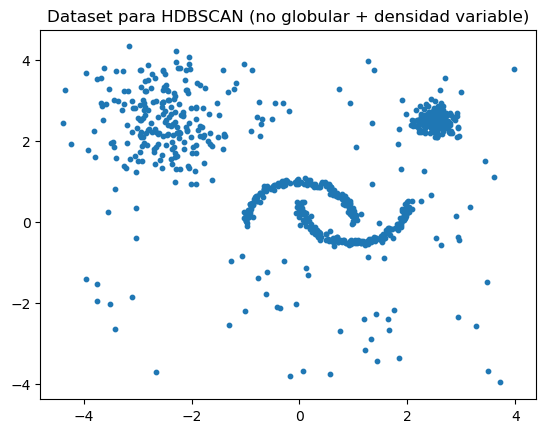

In [10]:
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Dataset para HDBSCAN (no globular + densidad variable)")
plt.show()

### Implementación de HDBSCAN paso a paso

#### Matriz de distancias $D$

Definición: 

$$D_{ij} = d(x_i, x_j)$$

Propiedades matemáticas:

* No negatividad: $D_{ij} \ge 0$
* Identidad del indiscernible: $D_{ii} = 0$
* Simetría: $D_{ij} = D_{ji}$

In [11]:
def pairwise_distances(X):
    n = X.shape[0]
    D = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(X[i] - X[j])
            D[i, j] = dist
            D[j, i] = dist
            
    return D

In [13]:
D = pairwise_distances(X)

In [12]:
D_check = cdist(X, X, metric='euclidean')

In [14]:
D

array([[0.        , 1.04605612, 1.67589519, ..., 2.6039153 , 1.75597455,
        2.77144517],
       [1.04605612, 0.        , 0.63031653, ..., 1.65810518, 0.71024785,
        2.43404986],
       [1.67589519, 0.63031653, 0.        , ..., 1.19746597, 0.09955932,
        2.40282879],
       ...,
       [2.6039153 , 1.65810518, 1.19746597, ..., 0.        , 1.10082701,
        3.47058349],
       [1.75597455, 0.71024785, 0.09955932, ..., 1.10082701, 0.        ,
        2.47287804],
       [2.77144517, 2.43404986, 2.40282879, ..., 3.47058349, 2.47287804,
        0.        ]])

In [15]:
D_check

array([[0.        , 1.04605612, 1.67589519, ..., 2.6039153 , 1.75597455,
        2.77144517],
       [1.04605612, 0.        , 0.63031653, ..., 1.65810518, 0.71024785,
        2.43404986],
       [1.67589519, 0.63031653, 0.        , ..., 1.19746597, 0.09955932,
        2.40282879],
       ...,
       [2.6039153 , 1.65810518, 1.19746597, ..., 0.        , 1.10082701,
        3.47058349],
       [1.75597455, 0.71024785, 0.09955932, ..., 1.10082701, 0.        ,
        2.47287804],
       [2.77144517, 2.43404986, 2.40282879, ..., 3.47058349, 2.47287804,
        0.        ]])

Verificación de propiedades matemáticas


In [16]:
# simetría
np.allclose(D, D.T)

True

In [17]:
# diagonal cero
np.allclose(np.diag(D), 0)

True

In [ ]:
# no negatividad

np.all(D >= 0)

True

#### Core distance

Definición para cada punto $x_i$:

$$\text{core}_k(x_i) = \text{distancia al } k\text{-ésimo vecino más cercano}$$

donde  $$k = \text{min\_samples}$$


Propiedades matemáticas:

* No negatividad: $c_i \ge 0$
* Consistencia con $D$, para cada $i$: $c_i = \text{k-ésimo valor ordenado de } \{D_{ij}\}_{j \ne i}$
* Monotonicidad en $k$, si $k_1 < k_2$:$ c_i^{(k_1)} \le c_i^{(k_2)}$

In [22]:
def core_distances(D, k):
    n = D.shape[0]
    core = np.zeros(n)
    
    for i in range(n):
        # ordenar distancias (ignorando el 0 a sí mismo)
        sorted_distances = np.sort(D[i])
        
        # índice k porque el primero es 0 (distancia a sí mismo)
        core[i] = sorted_distances[k]
    
    return core

In [27]:
k = 5

In [28]:
core = core_distances(D= D, k=k)

Verificación de propiedades matemáticas


In [29]:
# no negatividad
np.all(core >= 0)

True

In [31]:
# consistencia con D
for i in range(len(core)):
    sorted_d = np.sort(D[i])
    assert np.isclose(core[i], sorted_d[k])

In [ ]:
# Monotonicidad en K: 
# verificar que las filas de D estén ordenadas es suficiente, la monotonicidad queda implícitamente garantizada

sorted_D = np.sort(D, axis=1)

# verificar que cada fila esté ordenada
np.all(sorted_D[:, :-1] <= sorted_D[:, 1:])

True

#### Mutual reachability distance

Definición clave: 

$$d_{\text{mreach}}(i,j) = \max \left\{
\text{core}(i),\;
\text{core}(j),\;
D_{ij}
\right\}$$


Propiedades matemáticas:

* Simetría: $M_{ij} = M_{ji}$
*  Dominancia $M_{ij} \ge D_{ij}$: $M_{ij} \ge c_i,\quad M_{ij} \ge c_j$
*  No negatividad: $M_{ij} \ge 0$
*  Diagonal: $M_{ii} = \max(c_i, c_i, 0) = c_i$

In [32]:
def mutual_reachability(D, core):
    n = D.shape[0]
    M = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            M[i, j] = max(core[i], core[j], D[i, j])
    
    return M

In [35]:
M = mutual_reachability(D= D, core = core)

In [36]:
M

array([[0.08207685, 1.04605612, 1.67589519, ..., 2.6039153 , 1.75597455,
        2.77144517],
       [1.04605612, 0.09960708, 0.63031653, ..., 1.65810518, 0.71024785,
        2.43404986],
       [1.67589519, 0.63031653, 0.09955932, ..., 1.19746597, 0.09955932,
        2.40282879],
       ...,
       [2.6039153 , 1.65810518, 1.19746597, ..., 0.08560154, 1.10082701,
        3.47058349],
       [1.75597455, 0.71024785, 0.09955932, ..., 1.10082701, 0.07641056,
        2.47287804],
       [2.77144517, 2.43404986, 2.40282879, ..., 3.47058349, 2.47287804,
        0.11752214]])

Verificación de propiedades matemáticas


In [37]:
# simetría
np.allclose(M, M.T)

True

In [38]:
# dominancia sobre D
np.all(M >= D)

True

In [39]:
# dominancia sobre core
for i in range(len(core)):
    assert np.all(M[i] >= core[i])
    assert np.all(M[:, i] >= core[i])

In [40]:
# diagonal correcta
np.allclose(np.diag(M), core)

True

Mutual reachability convierte el espacio métrico en uno donde
las regiones de baja densidad se vuelven más “lejanas”

Para dos puntos $x_i, x_j$:
- Si ambos están en región densa: $\text{core}(i), \text{core}(j)$ pequeños ⇒ $d_{\text{mreach}} \approx d(x_i, x_j)$
- Si uno está en región dispersa: core grande ⇒ distancia inflada

### MST Prim con mutual reachability on-demand

Definición:

$$\text{MST}(M) \equiv \text{MST usando } d_{\text{mreach}} \text{ on demand}$$ 

Donde: 

$$d_{\text{mreach}} \text{ on demand} = d_{\text{mreach}}(i,j) = \max(c_i, c_j, D_{ij})$$


#### Propiedades estructurales (definen un árbol)
- Número de aristas:|E| = n - 1
- Conectividad: \forall u,v \in V,\; \exists \text{ camino entre } u \text{ y } v
- Acyclicidad: \nexists \text{ ciclos en } T

#### Consistencia con la función de pesos (implementación)

- Para todo $v \neq root$: $key[v] = d_{\text{mreach}}(v, parent[v]) = \max(c_v, c_{parent[v]}, D_{v,parent[v]})$


#### Propiedad de corte (optimalidad local)

- Para toda arista $(u,v) \in T$, al removerla se induce un corte $(A,B)$: $w(u,v) \le w(i,j) \quad \forall i \in A,\; j \in B$

#### Minimalidad global (definición): No verificable directamente, pero garantizada por (3).

- $$T = \arg\min_{T'} \sum_{(i,j)\in T'} w(i,j)$$

In [43]:
def mreach(i, j, D, core):
    return max(core[i], core[j], D[i, j])

In [44]:
def prim_mst(D, core):
    n = len(D)
    
    in_mst = np.zeros(n, dtype=bool)
    key = np.full(n, np.inf)
    parent = np.full(n, -1)
    
    key[0] = 0
    
    for _ in range(n):
        # elegir nodo no incluido con menor key
        u = np.argmin(np.where(in_mst, np.inf, key))
        in_mst[u] = True
        
        for v in range(n):
            if not in_mst[v]:
                weight = mreach(u, v, D, core)
                
                if weight < key[v]:
                    key[v] = weight
                    parent[v] = u
    
    return parent, key

In [46]:
parent, key = prim_mst(D=D, core=core)

* parent[v] → nodo padre de v en el MST
* key[v] → peso de la arista (parent[v], v)

In [ ]:
# Número de aristas

assert np.sum(parent != -1) == n - 1

In [ ]:
# Conectividad

def is_connected(parent):
    n = len(parent)
    adj = [[] for _ in range(n)]
    
    for v in range(n):
        if parent[v] != -1:
            u = parent[v]
            adj[u].append(v)
            adj[v].append(u)
    
    visited = set()
    
    def dfs(u):
        visited.add(u)
        for w in adj[u]:
            if w not in visited:
                dfs(w)
    
    root = np.where(parent == -1)[0][0]
    dfs(root)
    
    return len(visited) == n

assert is_connected(parent)

In [ ]:
# Acyclicidad

assert np.sum(parent != -1) == n - 1
assert is_connected(parent)

In [ ]:
# Consistencia con la función de pesos

for v in range(n):
    if parent[v] != -1:
        assert np.isclose(
            key[v],
            max(core[v], core[parent[v]], D[v, parent[v]])
        )

In [ ]:
# Propiedad de corte (optimalidad local)

def check_cut_property(parent, key, D, core):
    n = len(parent)
    
    for v in range(n):
        u = parent[v]
        if u == -1:
            continue
        
        # construir componentes removiendo (u,v)
        adj = [[] for _ in range(n)]
        for i in range(n):
            if parent[i] != -1:
                a, b = i, parent[i]
                if not ((a == v and b == u) or (a == u and b == v)):
                    adj[a].append(b)
                    adj[b].append(a)
        
        # DFS para componente A
        visited = set()
        def dfs(x):
            visited.add(x)
            for y in adj[x]:
                if y not in visited:
                    dfs(y)
        
        dfs(v)
        A = visited
        B = set(range(n)) - A
        
        w_uv = key[v]
        
        # check condición de corte
        for i in A:
            for j in B:
                w_ij = max(core[i], core[j], D[i, j])
                if w_ij < w_uv - 1e-9:
                    return False
    
    return True

assert check_cut_property(parent, key, D, core)

### single linkage

### condensed tree


<font color="gray" size="2">

---

© Yané, Ian Cristian Ariel — CC BY-NC 4.0  
Material de autoría original. Uso no comercial. Requiere atribución.  
Ver licencia completa en el repositorio.

</font>